# ARMA 

In [1]:
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima_process import ArmaProcess

import matplotlib.pyplot as plt
import numpy as np

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
plt.rcParams['figure.figsize'] = [10, 7.5]

## Simulate ARMA process (1,1) 

In [3]:
ar1 = np.array([1, 0.33])
ma1 = np.array([1, 0.9])

In [4]:
ARMA_11 = ArmaProcess(ar1, ma1).generate_sample(nsample=1000)

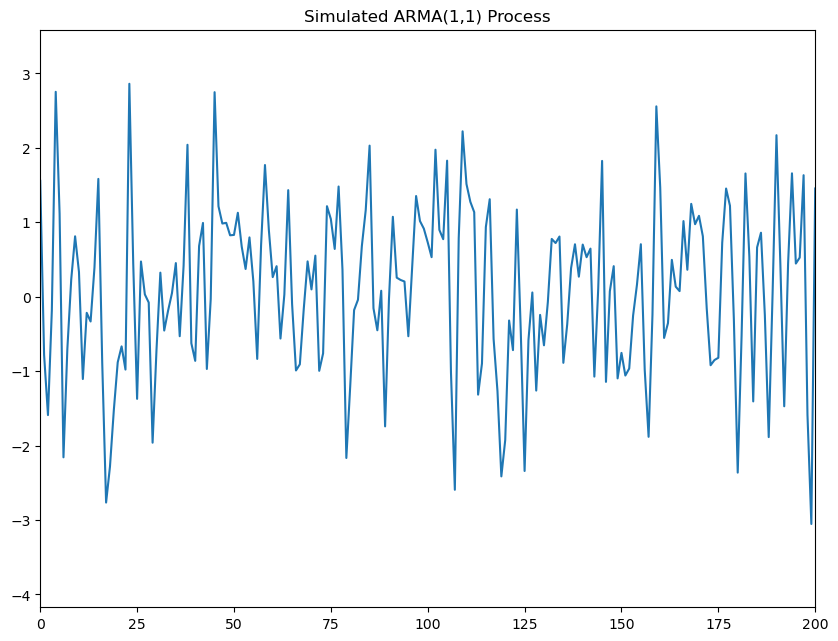

In [5]:
plt.plot(ARMA_11)
plt.title("Simulated ARMA(1,1) Process")
plt.xlim([0, 200])
plt.show()

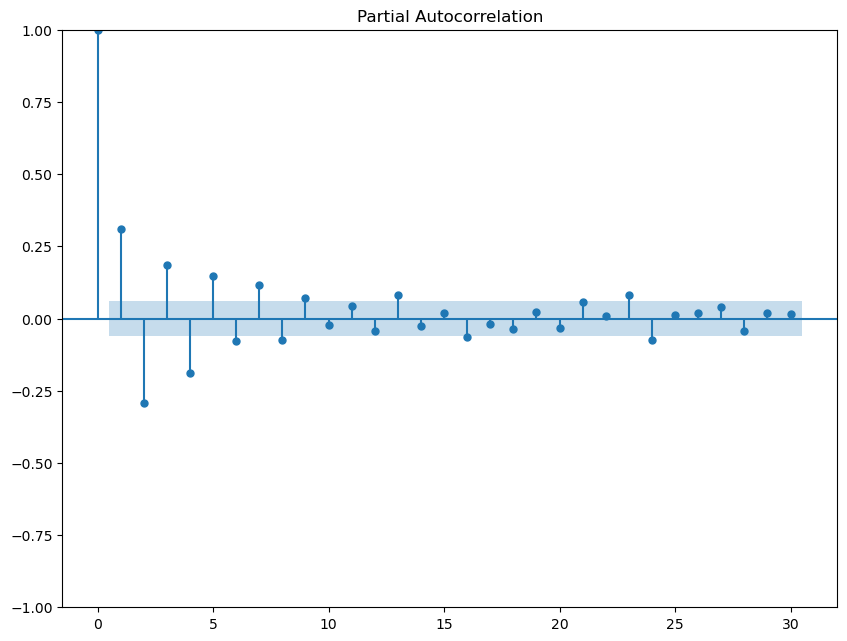

In [6]:
plot_pacf(ARMA_11)

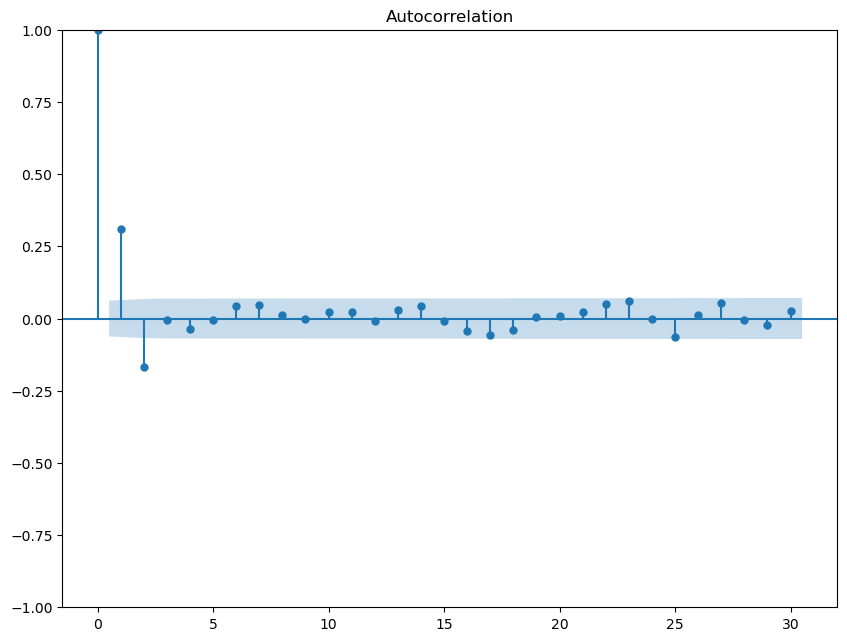

In [7]:
plot_acf(ARMA_11)

## Simulate ARMA(2,2) process 

In [8]:
ar2 = np.array([1, 0.33, 0.5])
ma2 = np.array([1, 0.9, 0.3])

In [9]:
ARMA_22 = ArmaProcess(ar2, ma2).generate_sample(nsample=10000)

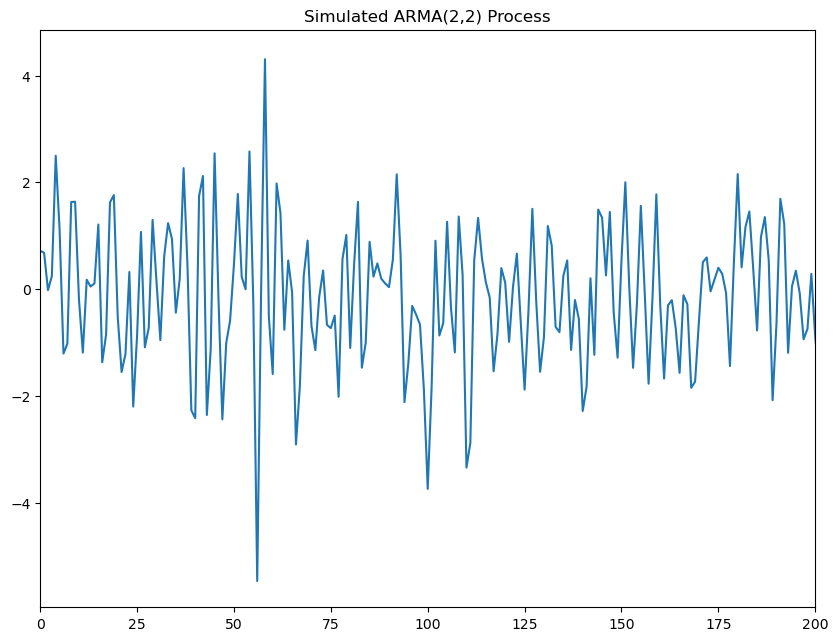

In [11]:
plt.plot(ARMA_22)
plt.title("Simulated ARMA(2,2) Process")
plt.xlim([0, 200])
plt.show()

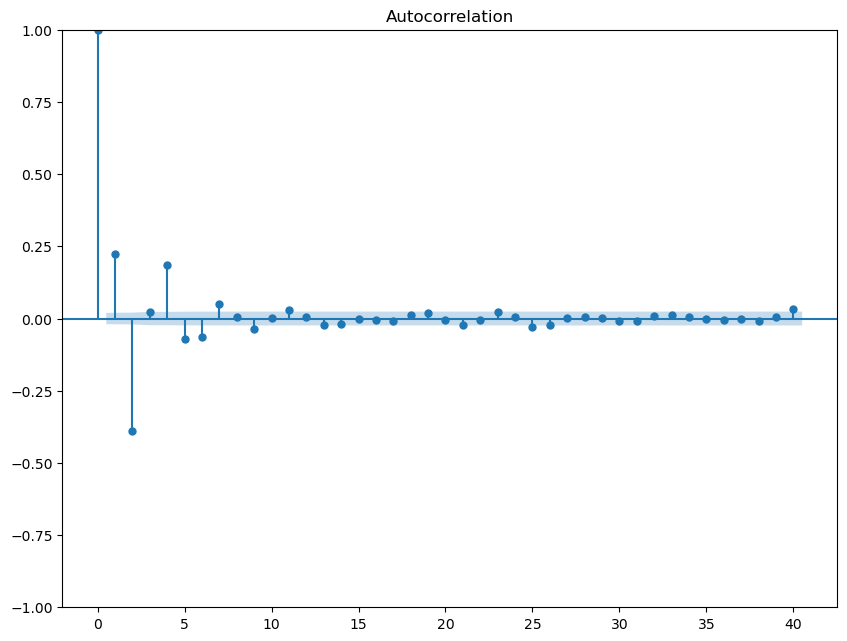

In [12]:
plot_acf(ARMA_22)

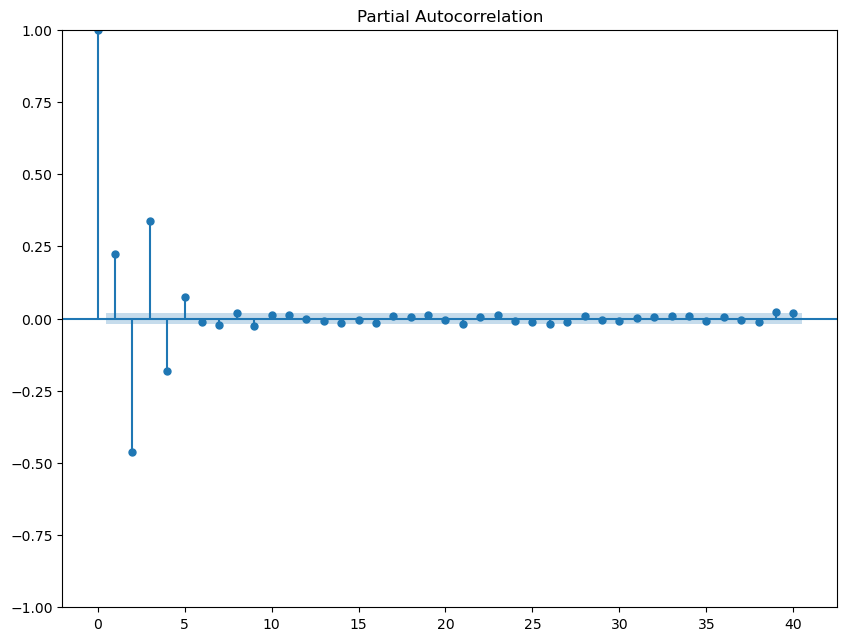

In [14]:
plot_pacf(ARMA_22)

In [15]:
from statsmodels.tsa.arima.model import ARIMA
ARMA_model = ARIMA(ARMA_22, order=(2,0,2), enforce_stationarity=False).fit()

print(ARMA_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                10000
Model:                 ARIMA(2, 0, 2)   Log Likelihood              -14120.856
Date:                Thu, 10 Sep 2026   AIC                          28253.712
Time:                        19:19:59   BIC                          28296.972
Sample:                             0   HQIC                         28268.356
                              - 10000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0071      0.012     -0.592      0.554      -0.030       0.016
ar.L1         -0.3642      0.022    -16.522      0.000      -0.407      -0.321
ar.L2         -0.5048      0.011    -45.134      0.0